In [ ]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [ ]:
mp_holistic = mp.solutions.holistic # Holistic model (the one that detects face, pose and hands (all in one))
mp_drawing = mp.solutions.drawing_utils # Drawing utilities (to draw the detected landmarks)

In [ ]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [ ]:
import mediapipe as mp

mp_drawing = mp.solutions.drawing_utils
mp_holistic = mp.solutions.holistic
mp_hands = mp.solutions.hands

def draw_landmarks(image, results):
    if results.face_landmarks:
        mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS)
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_hands.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_hands.HAND_CONNECTIONS)
    return image

In [ ]:
mp_holistic.POSE_CONNECTIONS??

Type:        frozenset
String form: frozenset({(15, 21), (16, 20), (18, 20), (3, 7), (14, 16), (23, 25), (28, 30), (11, 23), (27, 31), (6, 8), (15, 17), (24, 26), (16, 22), (4, 5), (5, 6), (29, 31), (12, 24), (23, 24), (0, 1), (9, 10), (1, 2), (0, 4), (11, 13), (30, 32), (28, 32), (15, 19), (16, 18), (25, 27), (26, 28), (12, 14), (17, 19), (2, 3), (11, 12), (27, 29), (13, 15)})
Length:      35
Docstring:  
frozenset() -> empty frozenset object
frozenset(iterable) -> frozenset object

Build an immutable unordered collection of unique elements.

In [ ]:
mp_drawing.draw_landmarks??

Signature:
mp_drawing.draw_landmarks(
    image: numpy.ndarray,
    landmark_list: mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[int, mediapipe.python.solutions.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2),
    connection_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[Tuple[int, int], mediapipe.python.solutions.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2),
    is_drawing_landmarks: bool = True,
)
Source:   
def draw_landmarks(
    image: np.ndarray,
    landmark_list: landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Optional[
        Union[DrawingSpec, Mapping[int, DrawingSpec]]
    ] = DrawingSpec(color=RED_

In [ ]:
# 1. New detection variables
cap = cv2.VideoCapture(0) 
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic: 
    # min_detection_confidence has to do with the confidence where the model detects human, and min_tracking_confidence
    # has to do with the confidence where the model tracks the detected face or body.

    while cap.isOpened():    
        # Read feed
        ret, frame = cap.read() 

        # Make detections
        image, results = mediapipe_detection(frame, holistic) 
        # results is the output of the model, which contains the detected landmarks for face, pose and hands.
        # We will use this results variable to draw the detected landmarks on the image.
        # image is the output image with the detected landmarks drawn on it, which we will display on the screen.
        print(results)
        
        # Draw landmarks
        draw_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows() # Break the camera feed and close any open windows

I0000 00:00:1778063070.543134   15605 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778063070.548631   15649 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778063070.611106   15641 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778063070.640154   15644 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778063070.642194   15643 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778063070.643356   15644 inference_feedback_manager.cc:114] Feedback manager requires a model with a single si

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

KeyboardInterrupt: 

In [ ]:
results

In [ ]:
print("The total number of face landmarks detected is:", len(results.face_landmarks.landmark))
print("The total number of pose landmarks detected is:", len(results.pose_landmarks.landmark))
print("The total number of left hand landmarks detected is:", len(results.left_hand_landmarks.landmark))
print("The total number of right hand landmarks detected is:", len(results.right_hand_landmarks.landmark))  

The total number of face landmarks detected is: 468
The total number of pose landmarks detected is: 33


AttributeError: 'NoneType' object has no attribute 'landmark'

: 

In [ ]:
draw_landmarks(image, results)

array([[[152, 154, 149],
        [151, 153, 148],
        [149, 152, 151],
        ...,
        [113, 112,  94],
        [107, 115, 103],
        [ 98, 107,  94]],

       [[151, 153, 148],
        [151, 153, 148],
        [149, 153, 148],
        ...,
        [ 91, 113, 101],
        [ 91, 113, 101],
        [ 87, 110,  97]],

       [[150, 152, 147],
        [151, 153, 148],
        [151, 153, 148],
        ...,
        [ 88, 109, 106],
        [ 77, 113,  98],
        [ 77, 113,  98]],

       ...,

       [[ 63,  86,  80],
        [ 63,  86,  80],
        [ 61,  85,  83],
        ...,
        [118, 130, 121],
        [119, 129, 125],
        [119, 129, 125]],

       [[ 53,  85,  85],
        [ 53,  85,  85],
        [ 61,  85,  81],
        ...,
        [120, 132, 123],
        [119, 129, 125],
        [120, 130, 126]],

       [[ 53,  85,  85],
        [ 53,  85,  85],
        [ 67,  84,  81],
        ...,
        [110, 134, 123],
        [126, 131, 123],
        [126, 131, 123]]

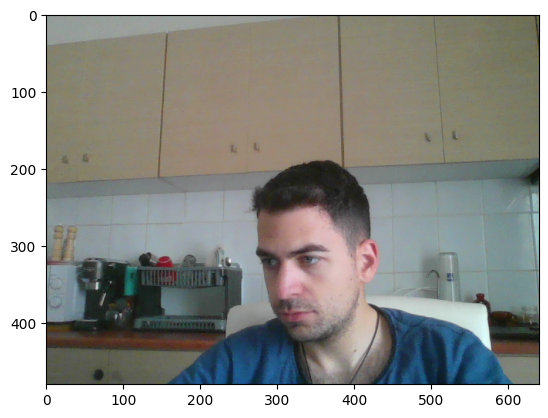

In [ ]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))